In [44]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from src.constants import STATE_CONFIG
from src.datasources import glofas, grrr
from src.utils.rp_calc import calculate_one_group_rp

ANALYSIS_START_YEAR = 1998
ANALYSIS_END_YEAR = 2024

In [45]:
STATE = "Adamawa"  # or "Benue"
cfg = STATE_CONFIG[STATE]

FIGURES_DIR = "figures"

## Load data

In [46]:
# GloFAS reanalysis — blob: ds-aa-nga-flooding/processed/glofas/glofas_reanalysis_{station}.parquet
df_gf = glofas.load_glofas_reanalysis(cfg["glofas_station"])

# Google GRRR reanalysis — GCS zarr: .../reanalysis/streamflow.zarr/
ds_grrr = grrr.load_reanalysis(gauge=cfg["google_gauge"])
df_grrr = grrr.process_reanalysis(ds_grrr)

# Floodscan pixel-level parquet — blob: cfg["floodscan_blob"]
df_fs_pixels = stratus.load_parquet_from_blob(cfg["floodscan_blob"])

## Wet-season annual maxima

In [47]:
# Floodscan: daily mean SFED across all pixels, then full-year annual max
# (consistent with 2025 analysis — no wet-season filter before annual max)
df_fs_daily = (
    df_fs_pixels.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "sfed_mean"})
)
df_fs_daily["date"] = pd.to_datetime(df_fs_daily["date"])
df_fs_daily = df_fs_daily[
    df_fs_daily["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

df_fs_annual = (
    df_fs_daily.assign(year=df_fs_daily["date"].dt.year)
    .groupby("year")["sfed_mean"]
    .max()
    .reset_index()
)
df_fs_annual = calculate_one_group_rp(df_fs_annual, col_name="sfed_mean", ascending=False)
fs_5yr = df_fs_annual["sfed_mean"].quantile(1 - 1 / 5)

In [48]:
# GloFAS: full-year annual max
df_gf["time"] = pd.to_datetime(df_gf["time"])
df_gf_annual = (
    df_gf.assign(year=df_gf["time"].dt.year)
    .groupby("year")["dis24"]
    .max()
    .reset_index()
)
df_gf_annual = df_gf_annual[
    df_gf_annual["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]
gf_5yr = df_gf_annual["dis24"].quantile(1 - 1 / 5)
# Use adopted threshold if set, otherwise fall back to empirical 5yr RP
glofas_thresh = cfg["glofas_thresh"] if cfg["glofas_thresh"] is not None else gf_5yr

# Google GRRR: full-year annual max
df_grrr["valid_time"] = pd.to_datetime(df_grrr["valid_time"])
df_grrr_annual = (
    df_grrr.assign(year=df_grrr["valid_time"].dt.year)
    .groupby("year")["streamflow"]
    .max()
    .reset_index()
)
df_grrr_annual = df_grrr_annual[
    df_grrr_annual["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]
grrr_5yr = df_grrr_annual["streamflow"].quantile(1 - 1 / 5)
# Use adopted threshold if set, otherwise fall back to empirical 5yr RP
google_thresh = cfg["google_thresh"] if cfg["google_thresh"] is not None else grrr_5yr

## Annual peak correlation

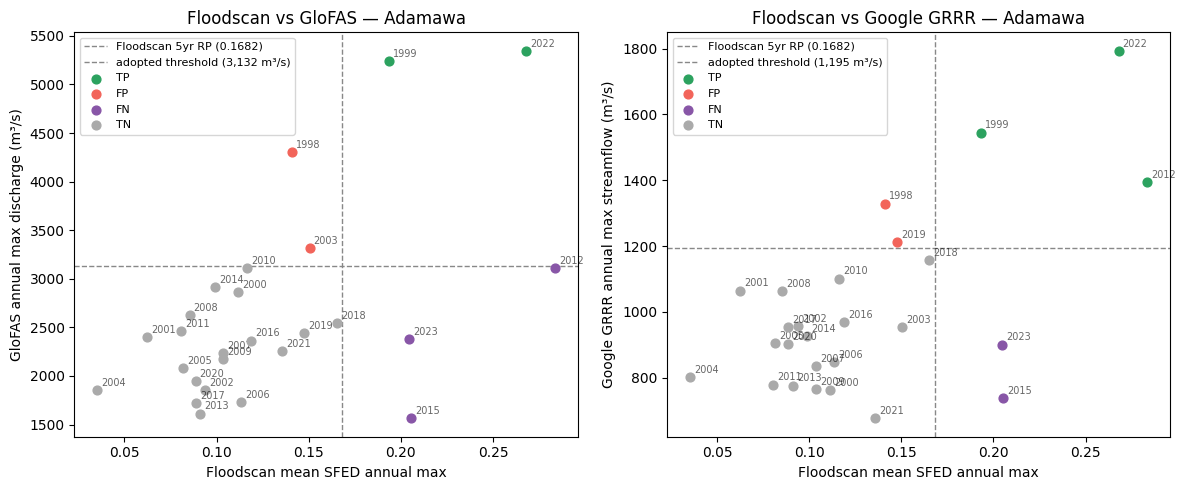

In [49]:
combined = (
    df_fs_annual.set_index("year")[["sfed_mean"]]
    .join(df_gf_annual.set_index("year")[["dis24"]], how="inner")
    .join(df_grrr_annual.set_index("year")[["streamflow"]], how="inner")
    .dropna()
)

CATEGORY_COLORS = {"TP": "#2ca25f", "FP": "#F2645A", "FN": "#8856a7", "TN": "#AAAAAA"}


def classify(trigger, event):
    if trigger and event:
        return "TP"
    elif trigger and not event:
        return "FP"
    elif not trigger and event:
        return "FN"
    else:
        return "TN"


thresh_label = "adopted threshold" if cfg["glofas_thresh"] is not None else "5yr RP"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_col, adopted_thresh, y_label in [
    (axes[0], "dis24",      glofas_thresh, "GloFAS annual max discharge (m³/s)"),
    (axes[1], "streamflow", google_thresh, "Google GRRR annual max streamflow (m³/s)"),
]:
    for year, row in combined.iterrows():
        event = row["sfed_mean"] > fs_5yr
        trigger = row[y_col] > adopted_thresh
        cat = classify(trigger, event)
        ax.scatter(row["sfed_mean"], row[y_col], color=CATEGORY_COLORS[cat], s=40, zorder=3)
        ax.annotate(
            str(year), (row["sfed_mean"], row[y_col]),
            fontsize=7, alpha=0.6, xytext=(3, 3), textcoords="offset points",
        )

    ax.axvline(fs_5yr, color="#888888", linestyle="--", linewidth=1,
               label=f"Floodscan 5yr RP ({fs_5yr:.4f})")
    ax.axhline(adopted_thresh, color="#888888", linestyle="--", linewidth=1,
               label=f"{thresh_label} ({adopted_thresh:,.0f} m³/s)")

    for cat, color in CATEGORY_COLORS.items():
        ax.scatter([], [], color=color, s=40, label=cat)

    ax.set_xlabel("Floodscan mean SFED annual max")
    ax.set_ylabel(y_label)
    ax.legend(fontsize=8)

axes[0].set_title(f"Floodscan vs GloFAS — {STATE}")
axes[1].set_title(f"Floodscan vs Google GRRR — {STATE}")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_peak_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## Rainy-season daily correlation

Pearson and Spearman correlation between daily model discharge and daily mean Floodscan SFED across all rainy-season days (Jun–Dec) in the analysis period.

In [50]:
WET_MONTHS = [8, 9, 10, 11, 12]

df_gf_wet = df_gf[df_gf["time"].dt.month.isin(WET_MONTHS)].copy()
df_gf_wet["date"] = df_gf_wet["time"].dt.normalize()

df_grrr_wet = df_grrr[df_grrr["valid_time"].dt.month.isin(WET_MONTHS)].copy()
df_grrr_wet["date"] = df_grrr_wet["valid_time"].dt.normalize()

df_fs_wet = df_fs_daily[
    df_fs_daily["date"].dt.month.isin(WET_MONTHS)
    & df_fs_daily["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()

df_daily = (
    df_fs_wet.set_index("date")[["sfed_mean"]]
    .join(df_gf_wet.set_index("date")[["dis24"]], how="inner")
    .join(df_grrr_wet.set_index("date")[["streamflow"]], how="inner")
    .dropna()
)

pd.DataFrame(
    {
        "GloFAS":      {"Pearson r":  df_daily["dis24"].corr(df_daily["sfed_mean"]),
                        "Spearman ρ": df_daily["dis24"].corr(df_daily["sfed_mean"], method="spearman"),
                        "n days":     len(df_daily)},
        "Google GRRR": {"Pearson r":  df_daily["streamflow"].corr(df_daily["sfed_mean"]),
                        "Spearman ρ": df_daily["streamflow"].corr(df_daily["sfed_mean"], method="spearman"),
                        "n days":     len(df_daily)},
    }
).T.round(3)

,Pearson r,Spearman ρ,n days
GloFAS,0.615,0.748,3970.0
Google GRRR,0.700,0.754,3970.0


## Precision, recall, F1

Event definition: Floodscan wet-season annual max exceeds 5-year RP threshold.  
Trigger: source reanalysis annual max exceeds threshold (`GLOFAS_THRESH` / `GOOGLE_THRESH` from constants).

In [51]:
years = list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))
df_eval = pd.DataFrame(index=years)

df_eval["event"]  = df_fs_annual.set_index("year")["sfed_mean"].reindex(df_eval.index).gt(fs_5yr).astype(int)
df_eval["glofas"] = df_gf_annual.set_index("year")["dis24"].reindex(df_eval.index).gt(glofas_thresh).astype(int)
df_eval["google"] = df_grrr_annual.set_index("year")["streamflow"].reindex(df_eval.index).gt(google_thresh).astype(int)
df_eval["or"]     = ((df_eval["glofas"] == 1) | (df_eval["google"] == 1)).astype(int)

df_eval = df_eval.dropna()


def prf(df, trigger_col, event_col="event"):
    tp = int(((df[trigger_col] == 1) & (df[event_col] == 1)).sum())
    fp = int(((df[trigger_col] == 1) & (df[event_col] == 0)).sum())
    fn = int(((df[trigger_col] == 0) & (df[event_col] == 1)).sum())
    p = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    r = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else float("nan")
    return {"TP": tp, "FP": fp, "FN": fn, "Precision": round(p, 2), "Recall": round(r, 2), "F1": round(f1, 2)}


metrics = pd.DataFrame(
    {
        "GloFAS reanalysis": prf(df_eval, "glofas"),
        "Google reanalysis": prf(df_eval, "google"),
        "OR trigger":        prf(df_eval, "or"),
    }
).T
metrics

,TP,FP,FN,Precision,Recall,F1
GloFAS reanalysis,3.0,2.0,3.0,0.60,0.50,0.55
Google reanalysis,3.0,2.0,3.0,0.60,0.50,0.55
OR trigger,4.0,3.0,2.0,0.57,0.67,0.62


In [52]:
# Year-by-year summary: event, trigger columns, and OR
df_eval.sort_index(ascending=False)

,event,glofas,google,or
2024,1,1,0,1
2023,1,0,0,0
2022,1,1,1,1
2021,0,0,0,0
2020,0,0,0,0
2019,0,0,1,1
2018,0,0,0,0
2017,0,0,0,0
2016,0,0,0,0
2015,1,0,0,0
